In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [16]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install matplotlib



Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


#read data

In [17]:
df=pd.read_csv('data/stud.csv')

In [18]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [19]:
df.shape

(1000, 8)

In [20]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [21]:
df.duplicate().sum()

AttributeError: 'DataFrame' object has no attribute 'duplicate'

In [22]:
df.duplicated().sum()

0

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [24]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

to check no of unique values

In [25]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [26]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [27]:
print("categories in gender variable: ",end=" ")
print(df['gender'].unique())

print("categories in race_ethnicity variable: ",end=" ")
print(df['race_ethnicity'].unique())

print("categories in parental_level_of_educationvariable: ",end=" ")
print(df['parental_level_of_education'].unique())

print("categories in lunch variable: ",end=" ")
print(df['lunch'].unique())

print("categories in test_prepration_course variable: ",end=" ")
print(df['test_preparation_course'].unique())

print("categories in math_score variable: ",end=" ")
print(df['math_score'].unique())

print("categories in reading_score variable: ",end=" ")
print(df['reading_score'].unique())

print("categories in writing_score variable: ",end=" ")
print(df['writing_score'].unique())

categories in gender variable:  ['female' 'male']
categories in race_ethnicity variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
categories in parental_level_of_educationvariable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in lunch variable:  ['standard' 'free/reduced']
categories in test_prepration_course variable:  ['none' 'completed']
categories in math_score variable:  [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
categories in reading_score variable:  [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49 

In [28]:
numeric_feature=[feature for feature in df.columns if df[feature].dtype !='O']
categorical_feature=[feature for feature in df.columns if df[feature].dtype =='O']

print('we have {} numeric features: {}'.format(len(numeric_feature), numeric_feature))
print('\n we have {} categorical features: {}'.format(len(categorical_feature), categorical_feature))

we have 3 numeric features: ['math_score', 'reading_score', 'writing_score']

 we have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


calculating total score and average

In [29]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average_score']=df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [30]:
reading_full=df[df['reading_score']==100]['average_score'].count()
print('number of student got full marks in reading score: {}'.format(reading_full))

writing_full=df[df['writing_score']==100]['average_score'].count()
print('number of student got full marks in writing score: {}'.format(writing_full))

Math_full=df[df['math_score']==100]['average_score'].count()
print('number of student got full marks in math score: {}'.format(Math_full))

number of student got full marks in reading score: 17
number of student got full marks in writing score: 14
number of student got full marks in math score: 7


In [31]:
reading_less_20=df[df['reading_score']<=20]['average_score'].count()
print('number of student got less than 20 in reading score: {}'.format(reading_less_20))

writing_less_20=df[df['writing_score']<=20]['average_score'].count()
print('number of student got less than 20 in writing score: {}'.format(writing_less_20))

Math_less_20=df[df['math_score']<=20]['average_score'].count()
print('number of student got less than 20 in math score: {}'.format(Math_less_20))

number of student got less than 20 in reading score: 1
number of student got less than 20 in writing score: 3
number of student got less than 20 in math score: 4


from above observation student perform worst in math and best in reading

exploring data (visulisation)

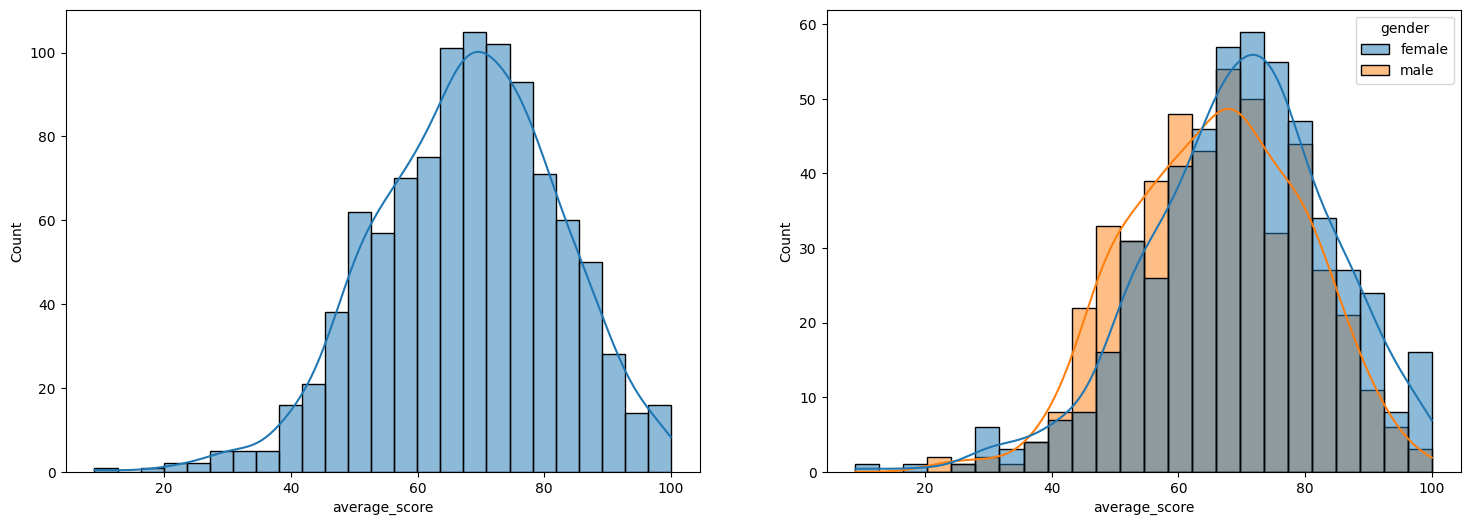

In [32]:
fig,axs=plt.subplots(1,3,figsize=(18,6))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=25,kde=True)
plt.subplot(122)
sns.histplot(data=df,x='average_score',hue='gender',kde=True)
plt.show()

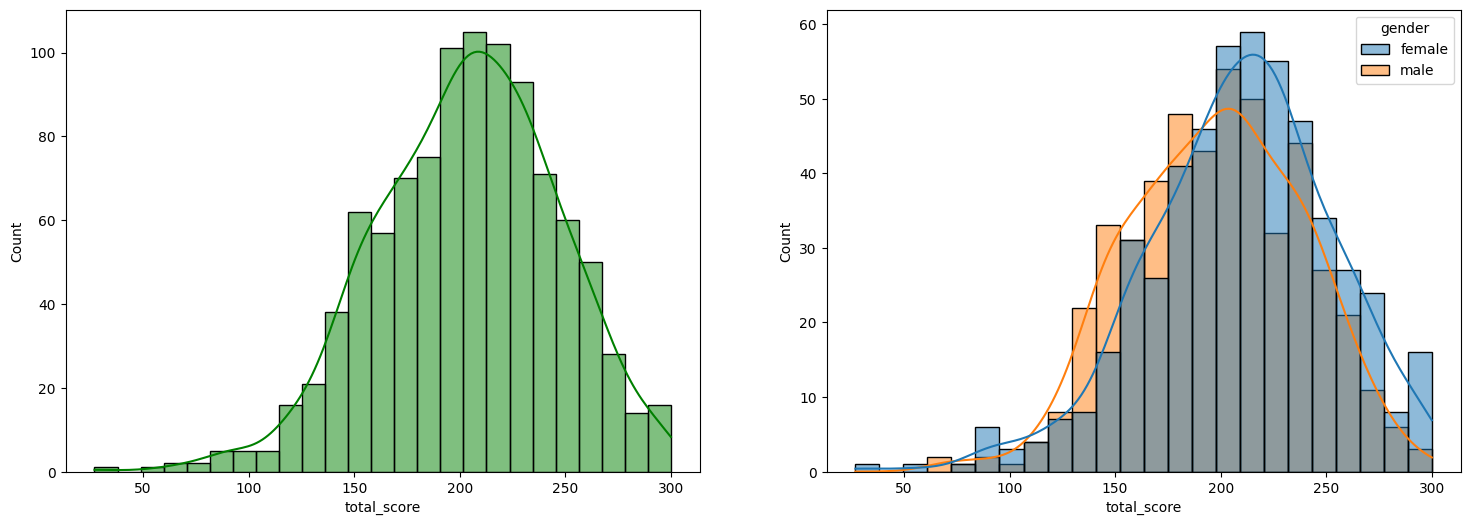

In [33]:
fig,axs=plt.subplots(1,2,figsize=(18,6))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=25,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',hue='gender',kde=True)
plt.show()